### Updating Package

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import pryngles as pr

### External Packages

In [26]:
import numpy as np
import pandas as pd

import rebound as rb

import matplotlib.pyplot as plt

%matplotlib inline

### Hierarchical N-Body System

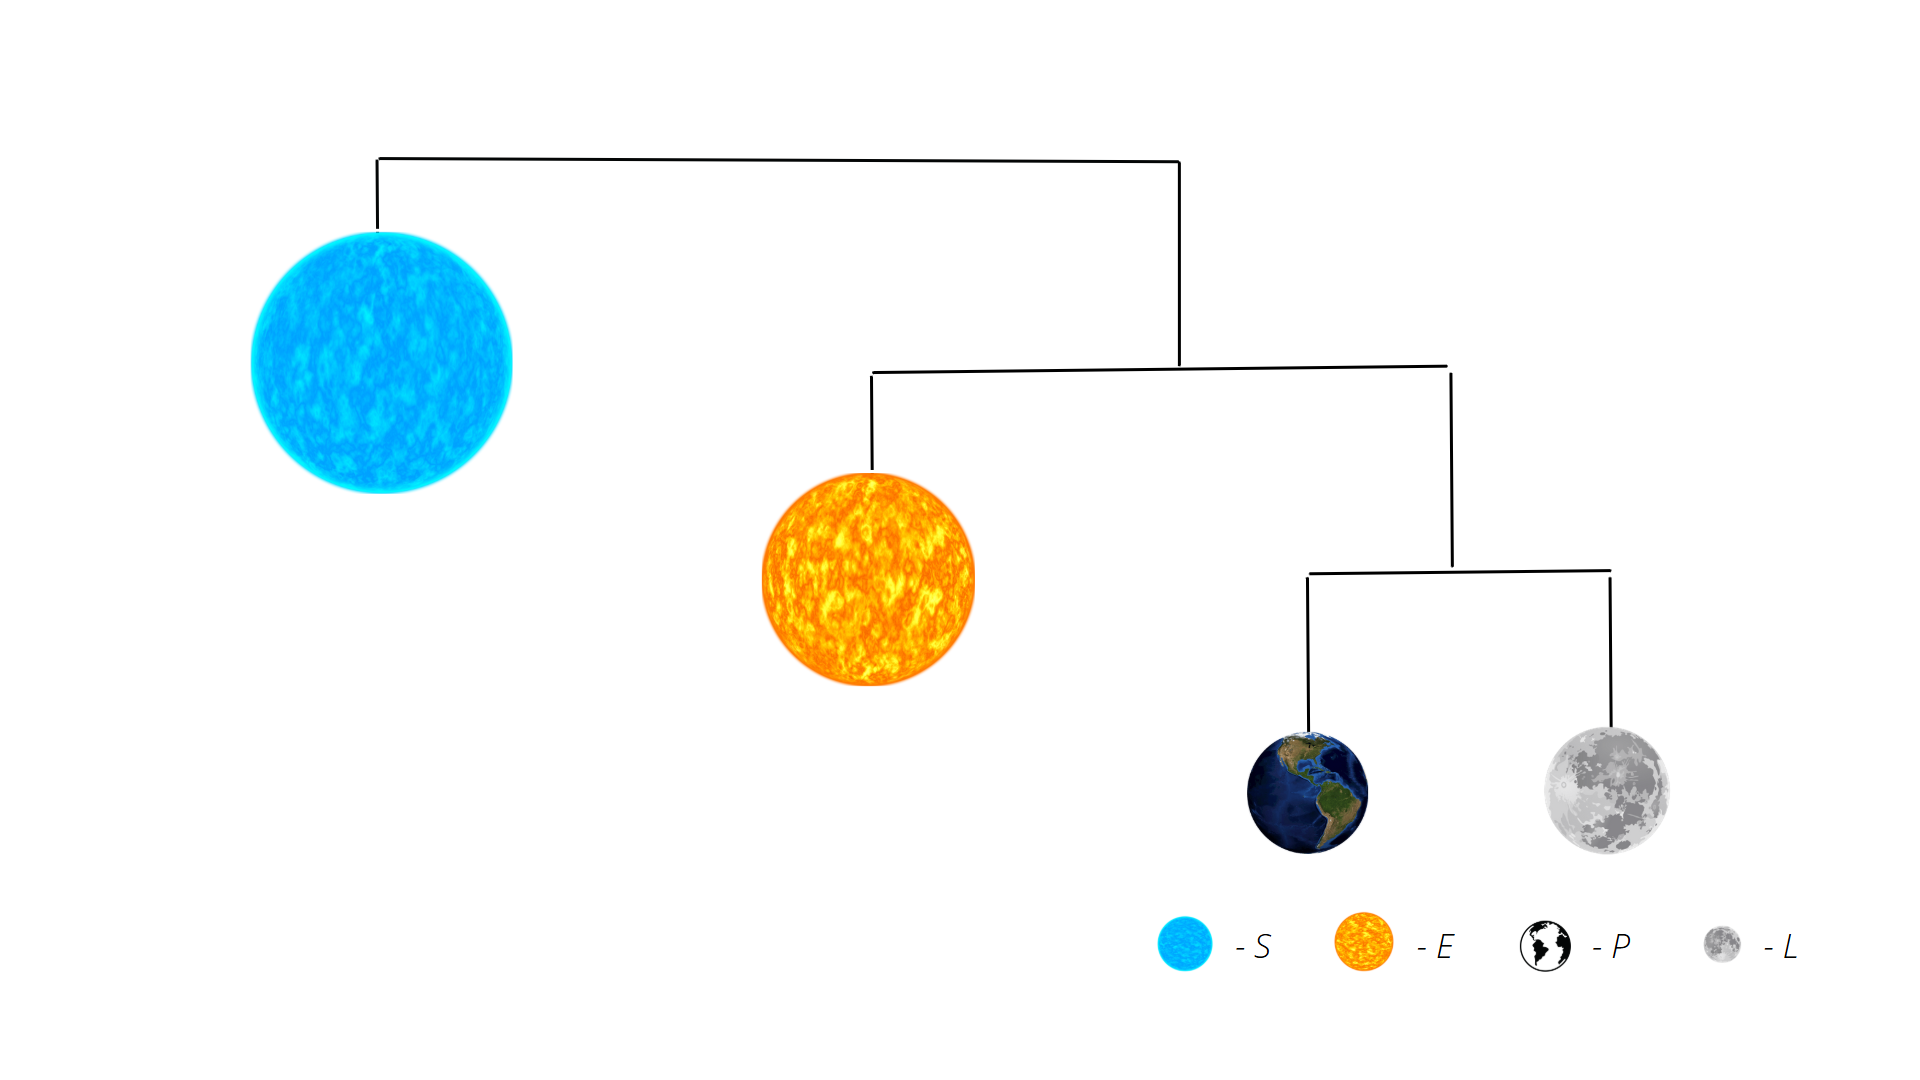

In [27]:
# Bodies masses
masses = np.array([1, 0.5, 0.01, 0.001])

# Inital positions respect each system
r0s = np.array([np.zeros(3), [2, 3, 0], #S-EPL System
                [0, 0.4, 0], #E-PL System
                [0.03, 0, 0]]) #P-L System

# Initial velocities respect each system
v0s = np.array([np.zeros(3), [-0.2, 0.7, 0.0], #S-EPL System
                [0.9, 0, 0.2], #E-PL System
                [0, 0.4, 0.1]]) #P-L System

In [28]:
system = pr.System()

bodies = np.zeros_like(masses, dtype = object)

for i in range(masses.shape[0]):

  bodies[i] = system.add(m = masses[i], name = f'Obj{i}',
                         parent = bodies[i-1] if i else None,
                        **dict(zip(['x','y','z','vx','vy','vz'],
                                    [*r0s[i], *v0s[i]])))

In [29]:
system.initialize_simulation()

In [30]:
ts = np.linspace(0, system.sim.orbit.Ps[0], 1000)

rs = np.zeros((masses.shape[0], 3, len(ts)))

for i, t in enumerate(ts):

  system.sim.integrate(t)

  for j, particle in enumerate(system.sim.particles):

    rs[j,:,i] = particle.xyz

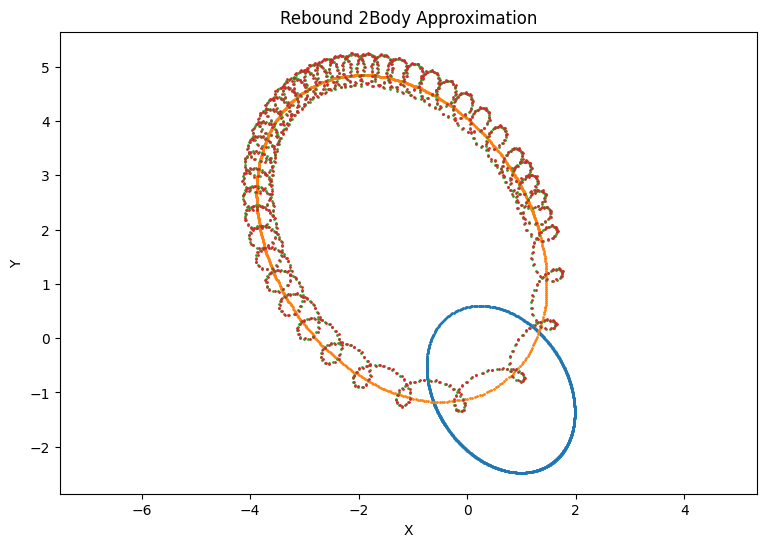

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))

for particle in rs:
    ax.scatter(particle[0], particle[1], s=1)

ax.set_aspect('equal', adjustable='datalim')

ax.set_title('Rebound 2Body Approximation')

ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

------

### OrbitUtil Class

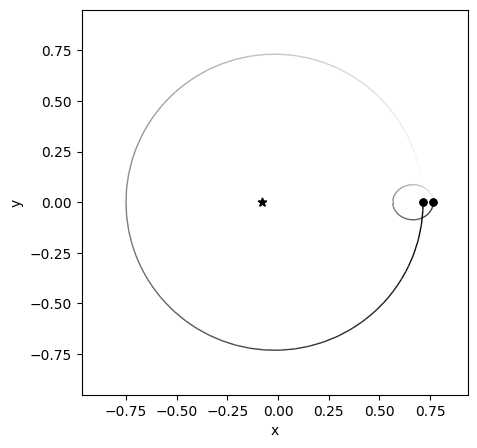

In [32]:
star = pr.Star(m = 1)
planet = pr.Planet(parent = star, m = 0.1, a = 1, e = 0.2)
moon = pr.Planet(parent = planet, m = 0.01, a = 0.1, e = 0.5)

orbital_tree = pr.OrbitUtil.build_tree(star)

orbit, _ = pr.OrbitUtil.build_system(orbital_tree)

orbit.calculate_orbit()
orbit.sim.move_to_com()

ob1 = rb.OrbitPlot(orbit.sim, particles = [1])

rb.OrbitPlot(orbit.sim, particles = [2], primary=1, 
             show_primary=False, fig=ob1.fig, ax = ob1.ax)

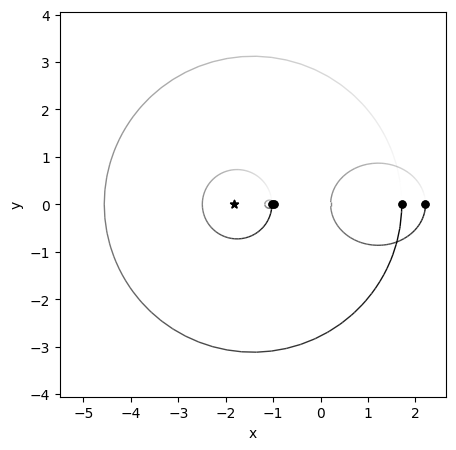

In [33]:
star = pr.Star(m = 1)
planet = pr.Planet(parent = star, m = 0.1, a = 1, e = 0.2)
moon = pr.Planet(parent = planet, m = 0.01, a = 0.1, e = 0.5)

star2 = pr.Star(parent = star, m = 1, a = 5, e = 0.3)
planet2 = pr.Planet(parent = star2, m = 0.1, e = 0.5)

orbital_tree = pr.OrbitUtil.build_tree(star)

orbit, _ = pr.OrbitUtil.build_system(orbital_tree)

orbit.calculate_orbit()
orbit.sim.move_to_com()

ob1 = rb.OrbitPlot(orbit.sim, particles = [1,3])

rb.OrbitPlot(orbit.sim, particles = [2], primary=1, 
             show_primary=False, fig=ob1.fig, ax = ob1.ax)

rb.OrbitPlot(orbit.sim, particles = [4], primary=3, 
             show_primary=False, fig=ob1.fig, ax = ob1.ax)

### Orbit Class

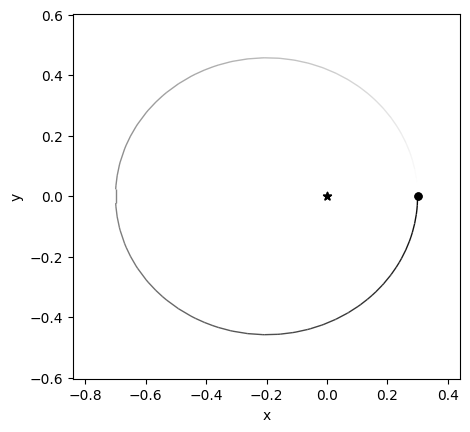

In [34]:
orbit = pr.Orbit(m1 = 1, m2 = 1e-3, a = 0.5, e = 0.4)
orbit.calculate_orbit()
orbit.sim.move_to_com()

rb.OrbitPlot(orbit.sim)

In [35]:
orbit.get_states()

(<rebound.simulation.Simulation object at 0x7b509773ee40, N=2, t=0.0>,
 [{'m': 1.0,
   'x': -0.0002997002997002997,
   'y': 0.0,
   'z': 0.0,
   'vx': 0.0,
   'vy': -0.002159167585437652,
   'vz': 0.0},
  {'m': 0.001,
   'x': 0.2997002997002997,
   'y': 0.0,
   'z': 0.0,
   'vx': 0.0,
   'vy': 2.1591675854376517,
   'vz': 0.0}])

In [36]:
system1 = pr.Orbit(m1 = 1, m2 = 0.1, a = 1, e = 0.4).calculate_orbit()
system2 = pr.Orbit(m1 = 1, m2 = 0.1, a = 1, e = 0.7).calculate_orbit()

# This is a way you can joint the above systems
system = pr.Orbit(m1 = system1, m2 = system2, a = 5, e = 0)
system.calculate_orbit()
system.sim.move_to_com()

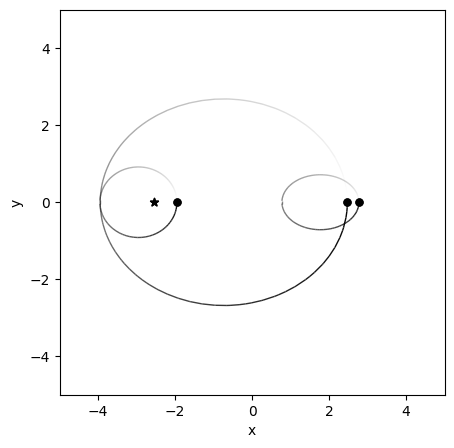

In [37]:
ob1 = rb.OrbitPlot(system.sim, particles = [1,2])

rb.OrbitPlot(system.sim, particles = [3], primary=2, 
             show_primary=False, fig=ob1.fig, ax = ob1.ax,
             xlim = [-5,5], ylim = [-5,5])